## Excercise 2 Rock Physics

#### Porosity against bulk modulus, only formation 10, generate background model, HM+HS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import lasio
import rockphypy as rp
from rockphypy import GM, EM

In [2]:
from pathlib import Path

# Robust path handling: try workspace-relative and absolute paths
possible_paths = [
    Path("Excerise_1") / "Datasets" / "Formation Tops.xlsx",
    Path("./Excerise_1") / "Datasets" / "Formation Tops.xlsx",
    Path("/workspaces/well_data_preprocessing/Excerise_1/Datasets/Formation Tops.xlsx")
]

tops_path = None
for p in possible_paths:
    if p.exists():
        tops_path = p
        break

if tops_path is None:
    raise FileNotFoundError(
        "Could not find 'Formation Tops.xlsx'. Expected one of: " +
        ", ".join(str(p) for p in possible_paths)
    )

df_tops = pd.read_excel(tops_path)
df_tops["Top depth [mMD_RKB]"] = df_tops["Top depth [mMD_RKB]"].astype("float64")

display(df_tops.head())
print("Loaded tops from:", tops_path)

,Well #,Formation,Top depth [mMD_RKB]
0,XX-X,FM-1,406.0
1,XX-X,FM-2,478.0
2,XX-X,FM-3,639.0
3,XX-X,FM-4,674.0
4,XX-X,FM-5,702.0


Loaded tops from: /workspaces/well_data_preprocessing/Excerise_1/Datasets/Formation Tops.xlsx


In [3]:
# --- Get FM-10 top and base (using top of FM-11 as base) ---
z_top10 = float(df_tops.loc[df_tops["Formation"]=="FM-10", "Top depth [mMD_RKB]"].iloc[0])
z_top11 = float(df_tops.loc[df_tops["Formation"]=="FM-11", "Top depth [mMD_RKB]"].iloc[0])
z0, z1 = z_top10, z_top11

print(f"FM-10 interval (mMD_RKB): {z0:.2f} to {z1:.2f}")


FM-10 interval (mMD_RKB): 1517.00 to 2141.00


In [4]:
# --- Robust path handling for LAS ---
possible_las_paths = [
    Path("Excerise_1") / "Datasets" / "Well Log.LAS",
    Path("./Excerise_1") / "Datasets" / "Well Log.LAS",
    Path("/workspaces/well_data_preprocessing/Excerise_1/Datasets/Well Log.LAS"),
    Path("/mnt/data/Well Log.LAS"),
]

las_path = None
for p in possible_las_paths:
    if p.exists():
        las_path = p
        break

if las_path is None:
    raise FileNotFoundError(
        "Could not find 'Well Log.LAS'. Expected one of:\n" +
        "\n".join(str(p) for p in possible_las_paths)
    )

las = lasio.read(las_path)
df_logs = las.df()
df_logs = df_logs.replace(-999.25, np.nan)
df_logs.index.name = "DEPT"
df_logs.head()

display(df_logs.head())
print("Loaded LAS from:", las_path)
print("Curves:", list(df_logs.columns))


,AC,ACS,BS,CALI,DEN,DENC,GR,K,NEU,PEF,RDEP,RMED,RMIC,ROP,TH,U
DEPT,,,,,,,,,,,,,,,,
405.9936,NaN,NaN,26.0,NaN,NaN,NaN,78.5885,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.1460,NaN,NaN,26.0,NaN,NaN,NaN,84.2673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.2984,NaN,NaN,26.0,NaN,NaN,NaN,83.9706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.4508,NaN,NaN,26.0,NaN,NaN,NaN,83.9938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.6032,NaN,NaN,26.0,NaN,NaN,NaN,76.8121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Loaded LAS from: /workspaces/well_data_preprocessing/Excerise_1/Datasets/Well Log.LAS
Curves: ['AC', 'ACS', 'BS', 'CALI', 'DEN', 'DENC', 'GR', 'K', 'NEU', 'PEF', 'RDEP', 'RMED', 'RMIC', 'ROP', 'TH', 'U']


In [5]:
# --- Velocity from sonic (AC, ACS in us/ft) -> m/s ---
# V = (1e6 / slowness_us_per_ft) * 0.3048
df_logs["Vp"] = (1e6 / df_logs["AC"])  * 0.3048
df_logs["Vs"] = (1e6 / df_logs["ACS"]) * 0.3048

# --- Porosity ---
# Keep density in g/cc (DEN is usually g/cc in LAS)
rho_ma = 2.65 # g/cc (quartz-ish)
rho_f  = 1.00 # g/cc (brine-ish)

df_logs["phi_D"] = (rho_ma - df_logs["DEN"]) / (rho_ma - rho_f)  # v/v
df_logs["phi_N"] = df_logs["NEU"]                               # usually v/v
df_logs["phi"]   = df_logs[["phi_D","phi_N"]].mean(axis=1)

# Clip to physical range
df_logs.loc[(df_logs["phi"] < 0) | (df_logs["phi"] > 0.60), "phi"] = np.nan

# --- Bulk modulus K [GPa] using rho in g/cc and V in m/s ---
# K[GPa] = 1e-3 * rho(g/cc) * (Vp^2 - 4/3 Vs^2)
df_logs["Kbulk_GPa"] = 1e-6 * df_logs["DEN"] * (df_logs["Vp"]**2 - (4.0/3.0)*df_logs["Vs"]**2)

# Basic sanity stats
display(df_logs[["Vp","Vs","DEN","phi","Kbulk_GPa", "GR"]].describe())

,Vp,Vs,DEN,phi,Kbulk_GPa,GR
count,9902.000000,9874.000000,9591.000000,9660.000000,9591.000000,11834.000000
mean,3376.580235,1756.009195,2.510800,0.146085,18.430447,108.183922
std,326.272733,276.538553,0.096185,0.039517,3.313977,25.675389
min,2334.303152,832.306831,2.101100,0.007171,5.660927,41.161500
25%,3184.851477,1579.379563,2.464300,0.122106,16.644970,94.010750
50%,3380.851605,1746.006969,2.541400,0.139523,18.531117,107.998900
75%,3572.791226,1934.759012,2.580600,0.158708,20.240718,118.692525
max,5714.232150,2932.788343,2.764100,0.392200,57.603265,540.817400


FM-10 samples: 4094


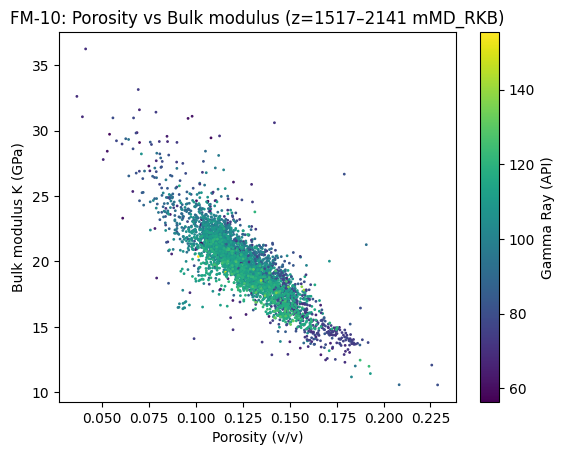

In [6]:
fm10 = df_logs.loc[(df_logs.index >= z0) & (df_logs.index < z1)].copy()
fm10 = fm10[np.isfinite(fm10["phi"]) & np.isfinite(fm10["Kbulk_GPa"]) & np.isfinite(fm10["GR"])]
print("FM-10 samples:", len(fm10))

plt.figure()
plt.scatter(fm10["phi"], fm10["Kbulk_GPa"], c=fm10["GR"], s=1)
plt.xlabel("Porosity (v/v)")
plt.ylabel("Bulk modulus K (GPa)")
plt.title(f"FM-10: Porosity vs Bulk modulus (z={z0:.0f}–{z1:.0f} mMD_RKB)")
plt.colorbar(label="Gamma Ray (API)")
plt.show()

In [7]:
# --- rockphypy HM + HS background model ---
# Docs:
# - GM.hertzmindlin(K0, G0, phic, Cn, sigma, f) returns (Khm, Ghm) in GPa, sigma in MPa
# - EM.HS(f1, K1, K2, G1, G2, bound='upper'/'lower') returns (Khs, Ghs) in GPa

# Parameters to tune
K0, G0 = 37.0, 44.0     # mineral moduli [GPa] (quartz-ish)
phi_c  = 0.40
Cn     = 9.0
sigma  = 20.0           # confining / effective pressure [MPa]
f_red  = 0.0            # reduced shear factor (0=no slip rough; 1=smooth slip)

# Hertz–Mindlin at critical porosity (returns GPa)
K_hm, G_hm = GM.hertzmindlin(K0, G0, phi_c, Cn, sigma, f_red)

# Build phi-grid and HS-lower trend (solid+void)
phi_grid = np.linspace(0.01, phi_c, 120)
f_solid = 1.0 - phi_grid

# "void" phase: K=0, G=0
K_void, G_void = 1e-6, 1e-6  # [GPa], small non-zero to avoid div-by-zero

# HS lower bound: (void, solid) ordering with bound='lower'
# f1=f_solid (solid phase), K1=K0, G1=G0 (solid moduli)
# f2=1-f_solid (void phase), K2=K_void, G2=G_void (void moduli)
K_bg, G_bg = EM.HS(f_solid, K0, K_void, G0, G_void, bound='lower')  # [GPa]

# Scale to match HM at critical porosity (phi_c)
# K_bg should approach K_hm as phi → phi_c (f_solid → 0)
if K_hm > 1e-9 and len(K_bg) > 0:
	K_bg = K_bg * (K_hm / K_bg[-1]) if K_bg[-1] > 1e-9 else K_bg
	G_bg = G_bg * (G_hm / G_bg[-1]) if G_bg[-1] > 1e-9 else G_bg

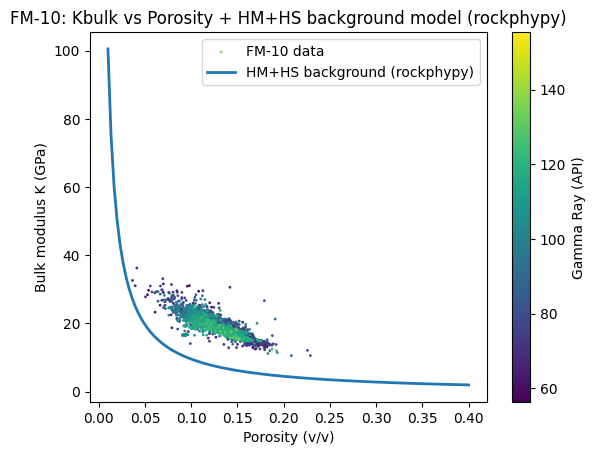

rockphypy HM: {'K_hm_GPa': 1.9500095457062927, 'G_hm_GPa': 1.1700057274237756}
rockphypy HS params: {'phi_c': 0.4, 'Cn': 9.0, 'sigma_MPa': 20.0, 'f_red': 0.0}


In [8]:
plt.figure()
plt.scatter(fm10["phi"], fm10["Kbulk_GPa"], c=fm10["GR"], s=1, label="FM-10 data")
plt.plot(phi_grid, K_bg, linewidth=2, label="HM+HS background (rockphypy)")
plt.xlabel("Porosity (v/v)")
plt.ylabel("Bulk modulus K (GPa)")
plt.colorbar(label="Gamma Ray (API)")
plt.title("FM-10: Kbulk vs Porosity + HM+HS background model (rockphypy)")
plt.legend()
plt.show()

print("rockphypy HM:", {"K_hm_GPa": float(K_hm), "G_hm_GPa": float(G_hm)})
print("rockphypy HS params:", {"phi_c": phi_c, "Cn": Cn, "sigma_MPa": sigma, "f_red": f_red})


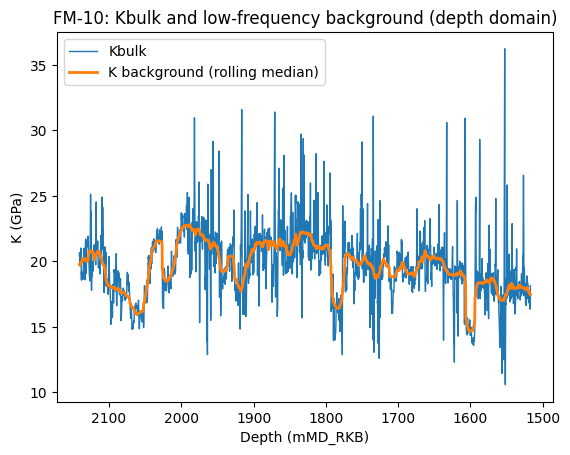

In [9]:
# Rolling median background in depth (choose window ~101 samples; adjust if needed)
fm10["K_bg_depth"]   = fm10["Kbulk_GPa"].rolling(window=101, center=True, min_periods=20).median()
fm10["phi_bg_depth"] = fm10["phi"].rolling(window=101, center=True, min_periods=20).median()

plt.figure()
plt.plot(fm10.index, fm10["Kbulk_GPa"], linewidth=1, label="Kbulk")
plt.plot(fm10.index, fm10["K_bg_depth"], linewidth=2, label="K background (rolling median)")
plt.gca().invert_xaxis()  # remove if you prefer depth increasing to the right
plt.xlabel("Depth (mMD_RKB)")
plt.ylabel("K (GPa)")
plt.title("FM-10: Kbulk and low-frequency background (depth domain)")
plt.legend()
plt.show()

In [10]:
out = fm10[["Vp","Vs","DEN","phi","Kbulk_GPa","K_bg_depth","phi_bg_depth"]].copy()
out_path = Path("fm10_rockphysics_outputs.csv")
out.to_csv(out_path, index=True)
display(out.head())

,Vp,Vs,DEN,phi,Kbulk_GPa,K_bg_depth,phi_bg_depth
DEPT,,,,,,,
1517.1420,3346.262407,1736.333636,2.5268,0.124283,18.136527,17.429100,0.142708
1517.2944,3155.919835,1586.098946,2.5553,0.132447,16.879162,17.430463,0.142425
1517.4468,3050.434247,1487.657277,2.5707,0.138130,16.335042,17.431826,0.142652
1517.5992,3043.641505,1431.383746,2.5747,0.140718,16.817789,17.483265,0.142397
1517.7516,3079.148668,1412.018464,2.5784,0.138297,17.591809,17.534703,0.142142
